# 02 – Random Forest

Nichtlineares Ensemble-Modell — Test auf H4 (nichtlinear > linear) und H2 (Zeitfeatures).

| Modell       | Features                                                                                          |
|--------------|---------------------------------------------------------------------------------------------------|
| **Model A**  | Strahlung + Wetter (4 Features, **ohne** Zeitfeatures)                                            |
| **Model B**  | + `interval_cos_shifted`, `month_cos_shifted`, `doy_cos_shifted` (**mit** Zeitfeatures)           |
| **Model C**  | + `Solarproduktion_lag_96` (24h-Lag, **mit** Zeit- & Lagfeatures)                                 |

**Forschungshypothesen:**
- **H2:** Zeitliche Merkmale verbessern die Prognose signifikant (MAE(mit Zeit) < MAE(ohne))
- **H4:** Nichtlineare Modelle übertreffen lineare Regression (MAE(RF) < MAE(linear))

## 0 · Setup

In [1]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from src.data.preprocessing import load_processed_data
from src.data.splitting import time_series_split, split_summary
from src.features.feature_engineering import add_lag_features
from src.features.feature_sets import FEATURE_SETS
from src.models.naive import fit_climatological_mean_by_season, predict_climatological_mean_by_season
from src.models.pipeline import run_pipeline, evaluate_on_test
from src.evaluation.metrics import evaluate, persistence_forecast

P_NOM = 13_500.0
TARGET = 'Solarproduktion'
RESULTS_DIR = Path('../../results/02_random_forest')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RUN_TEST = False  # flip to True once, deliberately, when finalizing results

FEATURES_A = FEATURE_SETS['BASE'].features
FEATURES_B = FEATURE_SETS['BASE_WITH_TIME'].features
FEATURES_C = FEATURE_SETS['BASE_WITH_TIME_AND_LAG'].features

RF_PARAMS = dict(n_estimators=300, max_features='sqrt',
                 min_samples_leaf=4, n_jobs=-1, random_state=42)

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

## 1 · Daten laden & Split

## 2 · Feature-Übersicht

Features werden aus `data/processed/features.csv` geladen (vorberechnet in `04_feature_engineering.ipynb`).

| Modell       | Features                                                                                          |
|--------------|---------------------------------------------------------------------------------------------------|
| **Model A**  | Strahlung + Wetter (4 Features, **ohne** Zeitfeatures)                                            |
| **Model B**  | + `interval_cos_shifted`, `month_cos_shifted`, `doy_cos_shifted` (**mit** Zeitfeatures)           |
| **Model C**  | + `Solarproduktion_lag_96` (24h-Lag)                                                             |

Für Model C wird der Lag auf dem vollen Datensatz berechnet (vor dem Split), damit keine Leakage entsteht.  
Anschließend werden separate Splits `train_c / val_c / test_c` mit `dropna` auf `FEATURES_C` erzeugt.

In [2]:
df = load_processed_data()
df = add_lag_features(df)                    # fügt Solarproduktion_lag_96 hinzu
train, val, test = time_series_split(df)

# A + B: ohne Lag (bestehende Splits)
train = train.dropna(subset=FEATURES_B + [TARGET])
val   = val.dropna(subset=FEATURES_B + [TARGET])
test  = test.dropna(subset=FEATURES_B + [TARGET])

# C: mit Lag (96 Zeilen am Split-Anfang werden entfernt)
train_c = train.dropna(subset=FEATURES_C + [TARGET])
val_c   = val.dropna(subset=FEATURES_C + [TARGET])
test_c  = test.dropna(subset=FEATURES_C + [TARGET])

split_summary(train, val, test)
print(f"\nModel C – Zeilen nach Lag-dropna: train={len(train_c):,}  val={len(val_c):,}  test={len(test_c):,}")


Model C – Zeilen nach Lag-dropna: train=82,242  val=17,645  test=17,641


## 4 · Modell trainieren

| Hyperparameter | Wert | Begründung |
|---|---|---|
| `n_estimators` | 300 | Genug Bäume für stabile OOB-Schätzung |
| `max_features` | `'sqrt'` | Standardwert für Regression; reduziert Korrelation zwischen Bäumen |
| `min_samples_leaf` | 4 | Verhindert Overfitting auf 15-min-Rauschen |
| `n_jobs` | -1 | Alle CPU-Kerne |
| `random_state` | 42 | Reproduzierbarkeit |

In [3]:
y_train = train.set_index('timestamp')[TARGET]
y_val   = val.set_index('timestamp')[TARGET]
y_test  = test.set_index('timestamp')[TARGET]

X_train = train.set_index('timestamp')[FEATURES_B]
X_val   = val.set_index('timestamp')[FEATURES_B]
X_test  = test.set_index('timestamp')[FEATURES_B]

y_train_c = train_c.set_index('timestamp')[TARGET]
y_val_c   = val_c.set_index('timestamp')[TARGET]
y_test_c  = test_c.set_index('timestamp')[TARGET]

X_train_c = train_c.set_index('timestamp')[FEATURES_C]
X_val_c   = val_c.set_index('timestamp')[FEATURES_C]
X_test_c  = test_c.set_index('timestamp')[FEATURES_C]

# Model A: ohne Zeitfeatures
model_a = RandomForestRegressor(**RF_PARAMS)
model_a.fit(X_train[FEATURES_A], y_train)

# Model B: mit Zeitfeatures
model_b = RandomForestRegressor(**RF_PARAMS)
model_b.fit(X_train[FEATURES_B], y_train)

# Model C: mit Zeit- und Lagfeatures
model_c = RandomForestRegressor(**RF_PARAMS)
model_c.fit(X_train_c[FEATURES_C], y_train_c)

# Lineare Regression als H4-Referenz
model_lin = LinearRegression()
model_lin.fit(X_train[FEATURES_B], y_train)

print(f'Model A (ohne Zeit):      {len(FEATURES_A)} Features')
print(f'Model B (mit Zeit):       {len(FEATURES_B)} Features')
print(f'Model C (mit Zeit + Lag): {len(FEATURES_C)} Features')

Model A (ohne Zeit):      4 Features
Model B (mit Zeit):       7 Features
Model C (mit Zeit + Lag): 8 Features


## 5 · Evaluation

Als Referenz-Baseline wird die **Day-Ahead-Persistenz** verwendet:

> **Persistenz-Naive:** Prognose für Tag *t* = gemessene Produktion von Tag *t−1*  
> (gleiche Uhrzeit, 96 × 15-min-Schritte zurück)

Skill Score > 0 bedeutet: das Modell schlägt diesen naiven Ansatz.

In [4]:
def rf_predict(model, X):
    return pd.Series(model.predict(X), index=X.index)

pred_a_val  = rf_predict(model_a, X_val[FEATURES_A])
pred_b_val  = rf_predict(model_b, X_val[FEATURES_B])
pred_c_val  = rf_predict(model_c, X_val_c[FEATURES_C])
pred_a_test = rf_predict(model_a, X_test[FEATURES_A])
pred_b_test = rf_predict(model_b, X_test[FEATURES_B])
pred_c_test = rf_predict(model_c, X_test_c[FEATURES_C])
pred_lin_val  = pd.Series(model_lin.predict(X_val[FEATURES_B]),  index=X_val.index)
pred_lin_test = pd.Series(model_lin.predict(X_test[FEATURES_B]), index=X_test.index)

pers_val  = persistence_forecast(y_val)
pers_test = persistence_forecast(y_test)
pers_val_c  = persistence_forecast(y_val_c)
pers_test_c = persistence_forecast(y_test_c)

clim_means      = fit_climatological_mean_by_season(train, TARGET)
clim_val_pred   = predict_climatological_mean_by_season(clim_means, val)
clim_val_pred.index  = y_val.index
clim_test_pred  = predict_climatological_mean_by_season(clim_means, test)
clim_test_pred.index = y_test.index

rows = {}
for name, yt, yp, yr in [
    ('Klimatologie (val)',           y_val,   clim_val_pred,  pers_val),
    ('Linear – mit Zeit (val)',      y_val,   pred_lin_val,   pers_val),
    ('RF A – ohne Zeit (val)',       y_val,   pred_a_val,     pers_val),
    ('RF B – mit Zeit (val)',        y_val,   pred_b_val,     pers_val),
    ('RF C – mit Zeit+Lag (val)',    y_val_c, pred_c_val,     pers_val_c),
    ('Klimatologie (test)',          y_test,  clim_test_pred, pers_test),
    ('Linear – mit Zeit (test)',     y_test,  pred_lin_test,  pers_test),
    ('RF A – ohne Zeit (test)',      y_test,  pred_a_test,    pers_test),
    ('RF B – mit Zeit (test)',       y_test,  pred_b_test,    pers_test),
    ('RF C – mit Zeit+Lag (test)',   y_test_c, pred_c_test,   pers_test_c),
]:
    rows[name] = evaluate(yt, yp, P_NOM, y_ref=yr)

results_df = pd.DataFrame(rows).T
results_df[['rmse', 'mae', 'r2', 'nrmse', 'skill_mae']].round(4)

,rmse,mae,r2,nrmse,skill_mae
Klimatologie (val),433.2560,184.4871,0.5561,0.0321,0.1275
Linear – mit Zeit (val),444.2984,240.5545,0.5332,0.0329,-0.1366
RF A – ohne Zeit (val),489.1273,238.9719,0.4342,0.0362,-0.1299
RF B – mit Zeit (val),395.7934,145.1892,0.6295,0.0293,0.3158
RF C – mit Zeit+Lag (val),393.4269,143.6931,0.6340,0.0291,0.3232
Klimatologie (test),461.3455,185.3174,0.4954,0.0342,0.1080
Linear – mit Zeit (test),451.2702,237.2306,0.5172,0.0334,-0.1394
RF A – ohne Zeit (test),475.7694,206.7654,0.4633,0.0352,0.0043
RF B – mit Zeit (test),365.6557,136.0301,0.6830,0.0271,0.3453
RF C – mit Zeit+Lag (test),368.6598,132.2644,0.6778,0.0273,0.3633


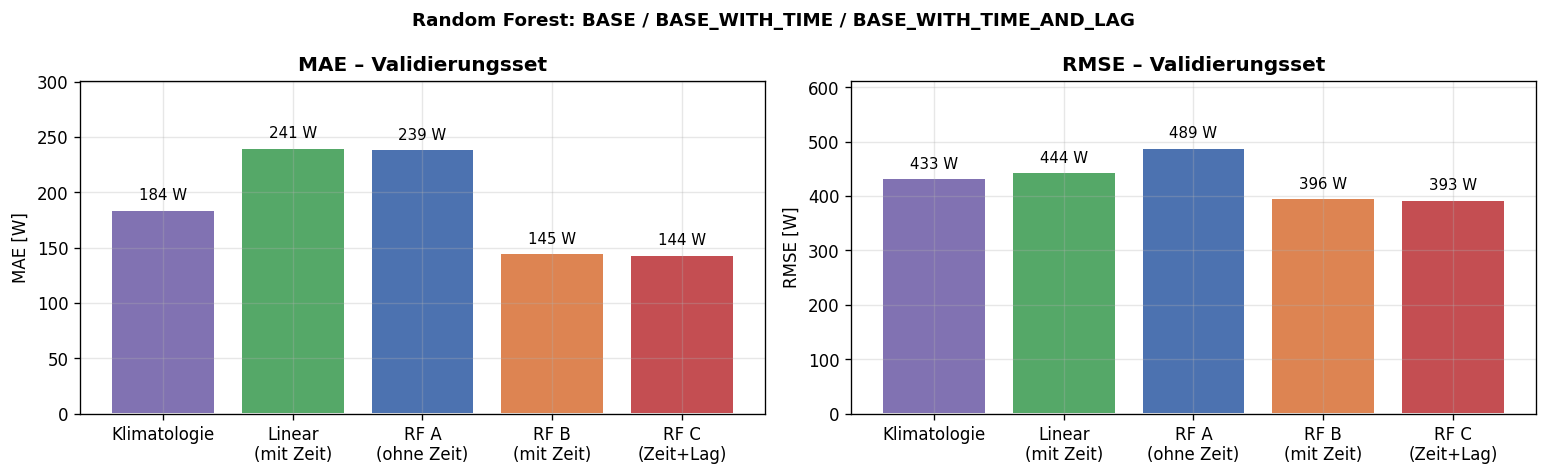

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

models = [
    'Klimatologie (val)',
    'Linear – mit Zeit (val)', 'RF A – ohne Zeit (val)',
    'RF B – mit Zeit (val)', 'RF C – mit Zeit+Lag (val)',
]
labels = ['Klimatologie', 'Linear\n(mit Zeit)', 'RF A\n(ohne Zeit)', 'RF B\n(mit Zeit)', 'RF C\n(Zeit+Lag)']
colors = ['#8172B2', '#55A868', '#4C72B0', '#DD8452', '#C44E52']

for ax, metric, title in [
    (axes[0], 'mae',  'MAE – Validierungsset'),
    (axes[1], 'rmse', 'RMSE – Validierungsset'),
]:
    vals = [results_df.loc[m, metric] for m in models]
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, fmt='%.0f W', padding=4, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric.upper()} [W]')
    ax.set_ylim(0, max(vals) * 1.25)

plt.suptitle('Random Forest: BASE / BASE_WITH_TIME / BASE_WITH_TIME_AND_LAG',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 · Beispielwoche

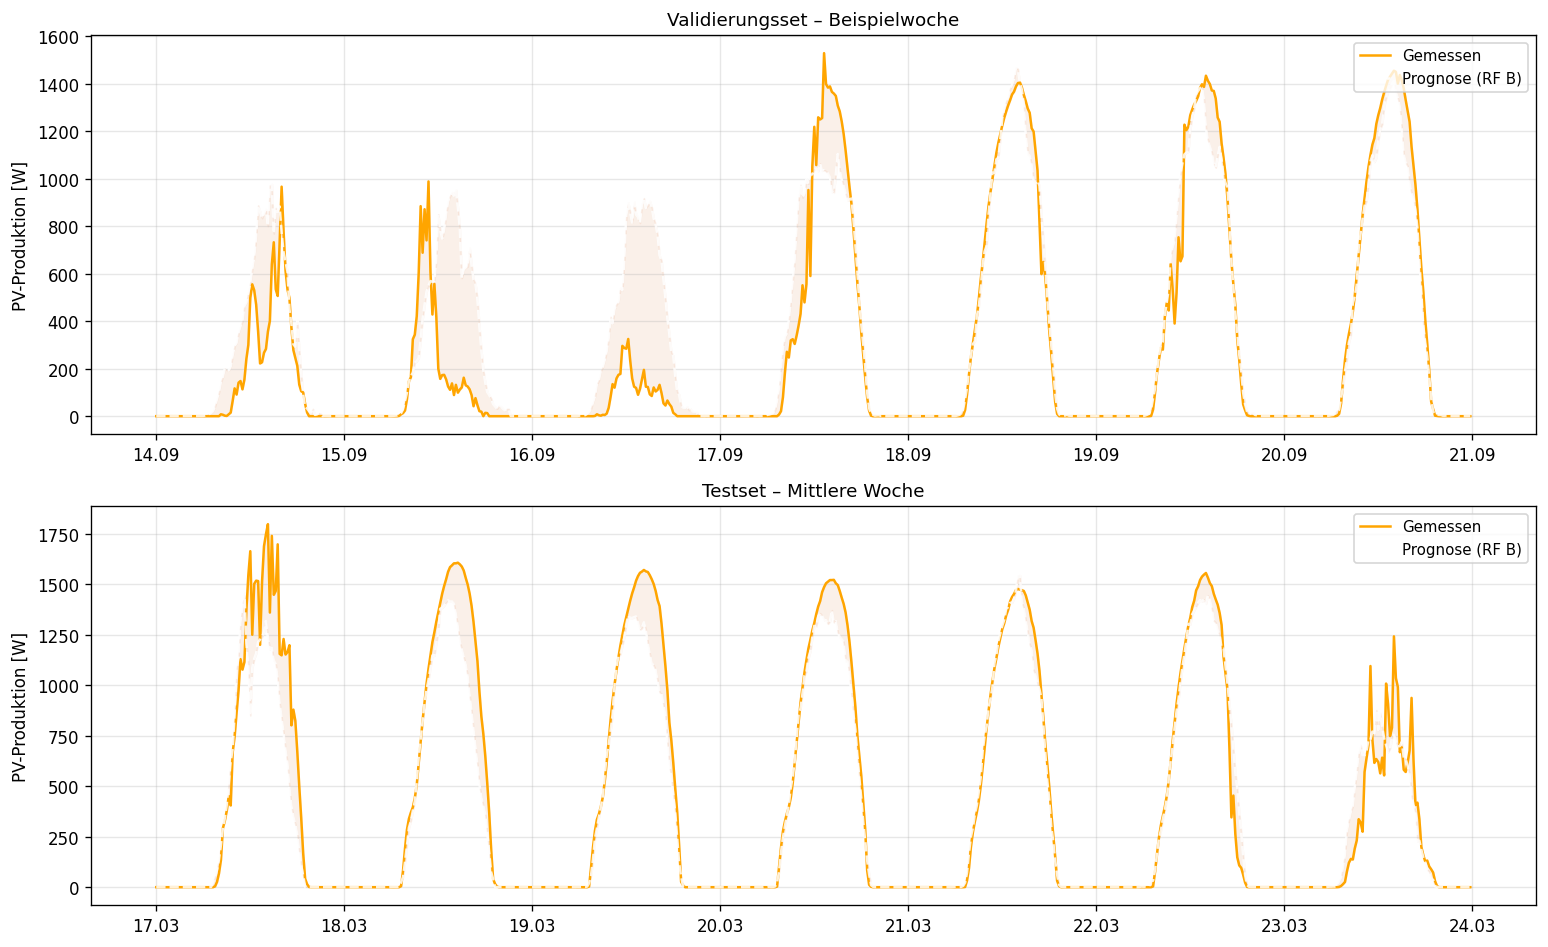

In [6]:
def plot_week(ax, df_split, y_pred, title):
    mid  = df_split['timestamp'].iloc[len(df_split) // 2].floor('D')
    mask = (df_split['timestamp'] >= mid) & (
           df_split['timestamp'] <  mid + pd.Timedelta(days=7))
    sub  = df_split[mask].set_index('timestamp')
    pred = y_pred.reindex(sub.index)
    ax.plot(sub.index, sub[TARGET], label='Gemessen',
            color='orange', linewidth=1.5)
    ax.plot(sub.index, pred, label='Prognose (RF B)',
            color='white', linewidth=1.5, linestyle='--', alpha=0.85)
    ax.fill_between(sub.index, sub[TARGET], pred, alpha=0.12, color='#DD8452')
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylabel('PV-Produktion [W]')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
plot_week(axes[0], val,  pred_b_val,  'Validierungsset – Beispielwoche')
plot_week(axes[1], test, pred_b_test, 'Testset – Mittlere Woche')
plt.tight_layout()
plt.show()

## 7 · Residualanalyse

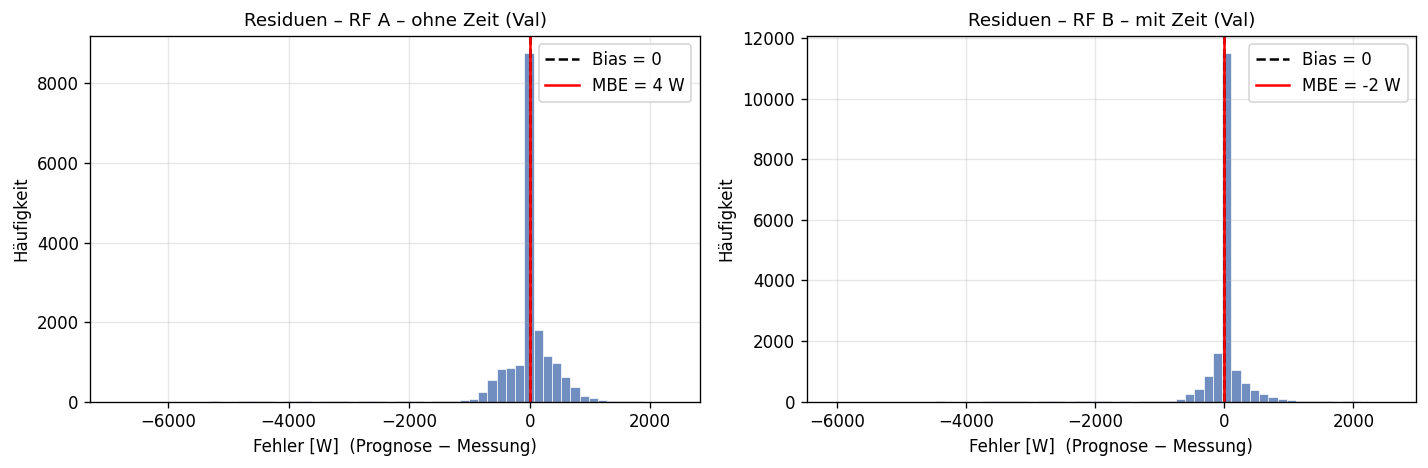

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, yt, yp in [
    (axes[0], 'RF A – ohne Zeit (Val)', y_val, pred_a_val),
    (axes[1], 'RF B – mit Zeit (Val)',  y_val, pred_b_val),
]:
    res = (yp - yt).dropna()
    ax.hist(res, bins=60, color='#4C72B0', edgecolor='white',
            linewidth=0.5, alpha=0.8)
    ax.axvline(0,          color='black', lw=1.5, ls='--', label='Bias = 0')
    ax.axvline(res.mean(), color='red',   lw=1.5, ls='-',
               label=f'MBE = {res.mean():.0f} W')
    ax.set_title(f'Residuen – {name}', fontsize=11)
    ax.set_xlabel('Fehler [W]  (Prognose − Messung)')
    ax.set_ylabel('Häufigkeit')
    ax.legend()

plt.tight_layout()
plt.show()

## 8 · Feature Importance

Mittlere Impurity-Reduktion (MDI) über alle Bäume — zeigt welche Features der Random Forest am stärksten nutzt.

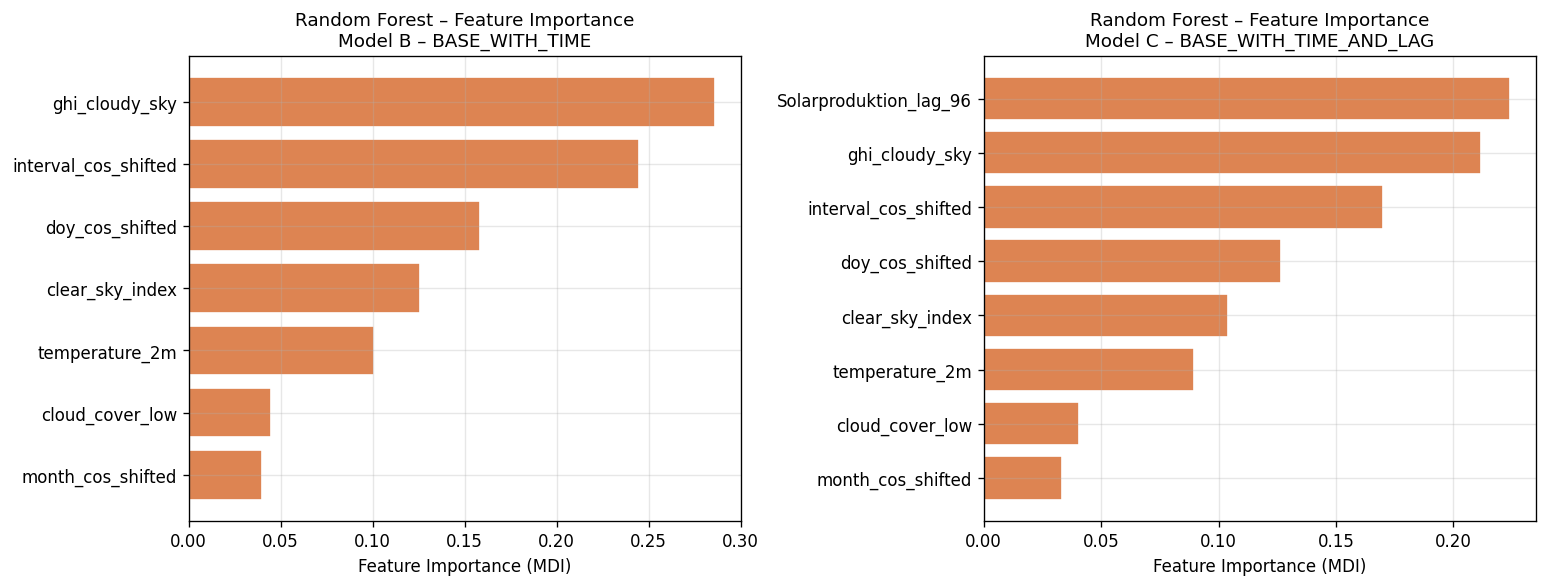

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, feats, title in [
    (axes[0], model_b, FEATURES_B, 'Model B – BASE_WITH_TIME'),
    (axes[1], model_c, FEATURES_C, 'Model C – BASE_WITH_TIME_AND_LAG'),
]:
    imp_df = pd.DataFrame({
        'feature':    feats,
        'importance': model.feature_importances_,
    }).set_index('feature').sort_values('importance')

    ax.barh(imp_df.index, imp_df['importance'], color='#DD8452', edgecolor='white')
    ax.set_xlabel('Feature Importance (MDI)')
    ax.set_title(f'Random Forest – Feature Importance\n{title}', fontsize=11)

plt.tight_layout()
plt.show()

## 9 · Ergebnisse speichern

In [9]:
def make_predict_fn(model):
    def predict_fn(df, features):
        X = df.set_index('timestamp')[features]
        return pd.Series(model.predict(X), index=X.index)
    return predict_fn

seasonal_means = fit_climatological_mean_by_season(train, TARGET)
ref_fn = lambda df, _: predict_climatological_mean_by_season(seasonal_means, df).set_axis(
    df.set_index('timestamp').index
)

# A + B: normale Splits
for model_name, model, fset in [
    ('random_forest_base',           model_a, 'BASE'),
    ('random_forest_base_with_time', model_b, 'BASE_WITH_TIME'),
]:
    feats = FEATURE_SETS[fset].features
    result = run_pipeline(
        model_name=model_name,
        predict_fn=make_predict_fn(model),
        train=train, val=val,
        features=feats, feature_set_key=fset,
        params=RF_PARAMS, results_dir=RESULTS_DIR,
        ref_predict_fn=ref_fn,
    )
    if RUN_TEST:
        evaluate_on_test(result, make_predict_fn(model), test, feats, RESULTS_DIR, ref_predict_fn=ref_fn)

# C: Lag-Splits
result_c = run_pipeline(
    model_name='random_forest_base_with_time_and_lag',
    predict_fn=make_predict_fn(model_c),
    train=train_c, val=val_c,
    features=FEATURES_C, feature_set_key='BASE_WITH_TIME_AND_LAG',
    params=RF_PARAMS, results_dir=RESULTS_DIR,
    ref_predict_fn=ref_fn,
)
if RUN_TEST:
    evaluate_on_test(result_c, make_predict_fn(model_c), test_c, FEATURES_C, RESULTS_DIR, ref_predict_fn=ref_fn)

Saved: ../../results/02_random_forest/random_forest_base.json
Saved predictions: ../../results/02_random_forest/random_forest_base_predictions_train.csv
Saved predictions: ../../results/02_random_forest/random_forest_base_predictions_val.csv


Saved: ../../results/02_random_forest/random_forest_base_with_time.json
Saved predictions: ../../results/02_random_forest/random_forest_base_with_time_predictions_train.csv
Saved predictions: ../../results/02_random_forest/random_forest_base_with_time_predictions_val.csv


Saved: ../../results/02_random_forest/random_forest_base_with_time_and_lag.json
Saved predictions: ../../results/02_random_forest/random_forest_base_with_time_and_lag_predictions_train.csv
Saved predictions: ../../results/02_random_forest/random_forest_base_with_time_and_lag_predictions_val.csv
